In [1]:
import torch.nn as nn
import numpy as np
from torchsummary import summary
from torchvision.datasets import MNIST
from sklearn.metrics import classification_report
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim
from tqdm import tqdm
import torch.nn.functional as F
import math

In [ ]:


# ─────────────────────────────────────────────────────────────
# Helper
# ─────────────────────────────────────────────────────────────
def make_divisible(value, divisor=8):
    new_value = max(divisor, int(value + divisor / 2) // divisor * divisor)
    if new_value < 0.9 * value:
        new_value += divisor
    return new_value


# ─────────────────────────────────────────────────────────────
# ConvBN  —  Conv2d + BatchNorm + ReLU
# ─────────────────────────────────────────────────────────────
class ConvBN(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        super(ConvBN, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size,
                      stride=stride, padding=(kernel_size - 1) // 2, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ─────────────────────────────────────────────────────────────
# UniversalInvertedBottleneck  — MobileNetV4
#
#  start_dw_kernel_size=0 , middle_dw_kernel_size>0  →  IB
#  start_dw_kernel_size>0 , middle_dw_kernel_size=0  →  ConvNext
#  start_dw_kernel_size>0 , middle_dw_kernel_size>0  →  ExtraDW
#  start_dw_kernel_size=0 , middle_dw_kernel_size=0  →  FFN
# ─────────────────────────────────────────────────────────────
class UniversalInvertedBottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio,
                 start_dw_kernel_size, middle_dw_kernel_size,
                 stride, middle_dw_downsample=True):
        super(UniversalInvertedBottleneck, self).__init__()

        self.start_dw_kernel_size  = start_dw_kernel_size
        self.middle_dw_kernel_size = middle_dw_kernel_size
        self.identity = (stride == 1 and in_channels == out_channels)

        # ① Optional start depthwise  (ConvNext / ExtraDW)
        if start_dw_kernel_size:
            self.start_dw_conv = nn.Conv2d(
                in_channels, in_channels,
                kernel_size=start_dw_kernel_size,
                stride=stride if not middle_dw_downsample else 1,
                padding=(start_dw_kernel_size - 1) // 2,
                groups=in_channels, bias=False
            )
            self.start_dw_norm = nn.BatchNorm2d(in_channels)

        # ② Expansion  (pointwise)
        expand_channels = make_divisible(in_channels * expand_ratio)
        self.expand_conv = nn.Conv2d(in_channels, expand_channels,
                                     kernel_size=1, bias=False)
        self.expand_norm = nn.BatchNorm2d(expand_channels)
        self.expand_act  = nn.ReLU(inplace=True)

        # ③ Optional middle depthwise  (IB / ExtraDW)
        if middle_dw_kernel_size:
            self.middle_dw_conv = nn.Conv2d(
                expand_channels, expand_channels,
                kernel_size=middle_dw_kernel_size,
                stride=stride if middle_dw_downsample else 1,
                padding=(middle_dw_kernel_size - 1) // 2,
                groups=expand_channels, bias=False
            )
            self.middle_dw_norm = nn.BatchNorm2d(expand_channels)
            self.middle_dw_act  = nn.ReLU(inplace=True)

        # ④ Projection  (pointwise)
        self.proj_conv = nn.Conv2d(expand_channels, out_channels,
                                   kernel_size=1, bias=False)
        self.proj_norm = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        shortcut = x

        if self.start_dw_kernel_size:
            x = self.start_dw_conv(x)
            x = self.start_dw_norm(x)

        x = self.expand_conv(x)
        x = self.expand_norm(x)
        x = self.expand_act(x)

        if self.middle_dw_kernel_size:
            x = self.middle_dw_conv(x)
            x = self.middle_dw_norm(x)
            x = self.middle_dw_act(x)

        x = self.proj_conv(x)
        x = self.proj_norm(x)

        return x + shortcut if self.identity else x


# ─────────────────────────────────────────────────────────────
# MobileNetV4-Conv-Small
# ─────────────────────────────────────────────────────────────
class MobileNetV4(nn.Module):
    def __init__(self, num_classes, input_channels=3):
        super(MobileNetV4, self).__init__()

        # ── Stem  224 → 112 → 56 ──────────────────────────────
        self.stem = nn.Sequential(
            ConvBN(input_channels, 32, kernel_size=3, stride=2),  # 112
            ConvBN(32, 32, kernel_size=3, stride=2),              # 56
            ConvBN(32, 32, kernel_size=1, stride=1),
        )

        # ── Stage 2  56 → 28 ──────────────────────────────────
        self.stage2 = nn.Sequential(
            ConvBN(32, 96, kernel_size=3, stride=2),              # 28
            ConvBN(96, 64, kernel_size=1, stride=1),
        )

        # ── Stage 3  28 → 14 ──────────────────────────────────
        self.stage3 = nn.Sequential(
            UniversalInvertedBottleneck(64,  96, expand_ratio=3.0,
                start_dw_kernel_size=5, middle_dw_kernel_size=5, stride=2),  # ExtraDW  28→14
            UniversalInvertedBottleneck(96,  96, expand_ratio=2.0,
                start_dw_kernel_size=0, middle_dw_kernel_size=3, stride=1),  # IB
            UniversalInvertedBottleneck(96,  96, expand_ratio=2.0,
                start_dw_kernel_size=0, middle_dw_kernel_size=3, stride=1),  # IB
            UniversalInvertedBottleneck(96,  96, expand_ratio=2.0,
                start_dw_kernel_size=0, middle_dw_kernel_size=3, stride=1),  # IB
            UniversalInvertedBottleneck(96,  96, expand_ratio=2.0,
                start_dw_kernel_size=0, middle_dw_kernel_size=3, stride=1),  # IB
            UniversalInvertedBottleneck(96,  96, expand_ratio=4.0,
                start_dw_kernel_size=3, middle_dw_kernel_size=0, stride=1),  # ConvNext
        )

        # ── Stage 4  14 → 7 ───────────────────────────────────
        self.stage4 = nn.Sequential(
            UniversalInvertedBottleneck(96,  128, expand_ratio=6.0,
                start_dw_kernel_size=3, middle_dw_kernel_size=3, stride=2),  # ExtraDW  14→7
            UniversalInvertedBottleneck(128, 128, expand_ratio=4.0,
                start_dw_kernel_size=5, middle_dw_kernel_size=5, stride=1),  # ExtraDW
            UniversalInvertedBottleneck(128, 128, expand_ratio=4.0,
                start_dw_kernel_size=0, middle_dw_kernel_size=5, stride=1),  # IB
            UniversalInvertedBottleneck(128, 128, expand_ratio=3.0,
                start_dw_kernel_size=0, middle_dw_kernel_size=5, stride=1),  # IB
            UniversalInvertedBottleneck(128, 128, expand_ratio=4.0,
                start_dw_kernel_size=0, middle_dw_kernel_size=3, stride=1),  # IB
            UniversalInvertedBottleneck(128, 128, expand_ratio=4.0,
                start_dw_kernel_size=0, middle_dw_kernel_size=3, stride=1),  # IB
        )

        # ── Head ──────────────────────────────────────────────
        self.conv_head  = ConvBN(128, 960, kernel_size=1, stride=1)
        self.avg_pool   = nn.AdaptiveAvgPool2d(1)
        self.flatten    = nn.Flatten()
        self.fc         = nn.Linear(960, num_classes)

        self._init_weights()

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.conv_head(x)
        x = self.avg_pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_summary = MobileNetV4(num_classes=101).to(device)
print(summary(model_summary, (3, 224, 224)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              ReLU-3         [-1, 32, 112, 112]               0
            ConvBN-4         [-1, 32, 112, 112]               0
            Conv2d-5           [-1, 32, 56, 56]           9,216
       BatchNorm2d-6           [-1, 32, 56, 56]              64
              ReLU-7           [-1, 32, 56, 56]               0
            ConvBN-8           [-1, 32, 56, 56]               0
            Conv2d-9           [-1, 32, 56, 56]           1,024
      BatchNorm2d-10           [-1, 32, 56, 56]              64
             ReLU-11           [-1, 32, 56, 56]               0
           ConvBN-12           [-1, 32, 56, 56]               0
           Conv2d-13           [-1, 96, 28, 28]          27,648
      BatchNorm2d-14           [-1, 96,

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets download -d dansbecker/food-101

Dataset URL: https://www.kaggle.com/datasets/dansbecker/food-101
License(s): other
100% 9.38G/9.38G [01:08<00:00, 147MB/s]



In [5]:
!rm -f food-101.zip
!rm -rf food-101

In [6]:
!ls -lh

total 4.0K
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


In [7]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
tmpfs           6.4G  224K  6.4G   1% /var/colab
/dev/sda1       119G   60G   60G  50% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware


In [8]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 14.4 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [9]:
!kaggle datasets download -d dansbecker/food-101

Dataset URL: https://www.kaggle.com/datasets/dansbecker/food-101
License(s): other
100% 9.38G/9.38G [01:07<00:00, 150MB/s]



In [10]:
!ls -lh food-101.zip

-rw-r--r-- 1 root root 9.4G Nov 21  2019 food-101.zip


In [11]:
!unzip -t food-101.zip

Streaming output truncated to the last 5000 lines.
    testing: food-101/food-101/images/tacos/1033196.jpg   OK
    testing: food-101/food-101/images/tacos/1036030.jpg   OK
    testing: food-101/food-101/images/tacos/1042175.jpg   OK
    testing: food-101/food-101/images/tacos/1044043.jpg   OK
    testing: food-101/food-101/images/tacos/1058697.jpg   OK
    testing: food-101/food-101/images/tacos/1059239.jpg   OK
    testing: food-101/food-101/images/tacos/1059326.jpg   OK
    testing: food-101/food-101/images/tacos/1066762.jpg   OK
    testing: food-101/food-101/images/tacos/1070967.jpg   OK
    testing: food-101/food-101/images/tacos/1073468.jpg   OK
    testing: food-101/food-101/images/tacos/1075296.jpg   OK
    testing: food-101/food-101/images/tacos/1085243.jpg   OK
    testing: food-101/food-101/images/tacos/108529.jpg   OK
    testing: food-101/food-101/images/tacos/1086014.jpg   OK
    testing: food-101/food-101/images/tacos/108945.jpg   OK
    testing: food-101/food-101/image

In [12]:
!unzip -o food-101.zip

Streaming output truncated to the last 5000 lines.
  inflating: food-101/food-101/images/tacos/1030289.jpg  
  inflating: food-101/food-101/images/tacos/1033196.jpg  
  inflating: food-101/food-101/images/tacos/1036030.jpg  
  inflating: food-101/food-101/images/tacos/1042175.jpg  
  inflating: food-101/food-101/images/tacos/1044043.jpg  
  inflating: food-101/food-101/images/tacos/1058697.jpg  
  inflating: food-101/food-101/images/tacos/1059239.jpg  
  inflating: food-101/food-101/images/tacos/1059326.jpg  
  inflating: food-101/food-101/images/tacos/1066762.jpg  
  inflating: food-101/food-101/images/tacos/1070967.jpg  
  inflating: food-101/food-101/images/tacos/1073468.jpg  
  inflating: food-101/food-101/images/tacos/1075296.jpg  
  inflating: food-101/food-101/images/tacos/1085243.jpg  
  inflating: food-101/food-101/images/tacos/108529.jpg  
  inflating: food-101/food-101/images/tacos/1086014.jpg  
  inflating: food-101/food-101/images/tacos/108945.jpg  
  inflating: food-101/f

In [13]:
import os
data_dir = './food-101/food-101/images'
classes = os.listdir(data_dir)
print("classes",classes)
print("num of classes",len(classes))
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  {cls}: {count} images")

classes ['prime_rib', 'baklava', 'peking_duck', 'filet_mignon', 'deviled_eggs', 'tacos', 'gyoza', 'caesar_salad', 'dumplings', 'french_onion_soup', 'bibimbap', 'ice_cream', 'french_toast', 'lobster_bisque', 'pho', 'fried_calamari', 'churros', 'beet_salad', 'chicken_curry', 'nachos', 'edamame', 'garlic_bread', 'pad_thai', 'samosa', 'steak', 'scallops', 'omelette', '.DS_Store', 'chicken_wings', 'seaweed_salad', 'strawberry_shortcake', 'bread_pudding', 'clam_chowder', 'beef_tartare', 'spaghetti_carbonara', 'oysters', 'donuts', 'chocolate_mousse', 'eggs_benedict', 'frozen_yogurt', 'takoyaki', 'club_sandwich', 'sushi', 'pork_chop', 'lobster_roll_sandwich', 'waffles', 'pulled_pork_sandwich', 'shrimp_and_grits', 'hot_and_sour_soup', 'tuna_tartare', 'creme_brulee', 'miso_soup', 'greek_salad', 'gnocchi', 'paella', 'cannoli', 'escargots', 'onion_rings', 'fish_and_chips', 'hot_dog', 'grilled_cheese_sandwich', 'lasagna', 'caprese_salad', 'huevos_rancheros', 'guacamole', 'beef_carpaccio', 'mussels'

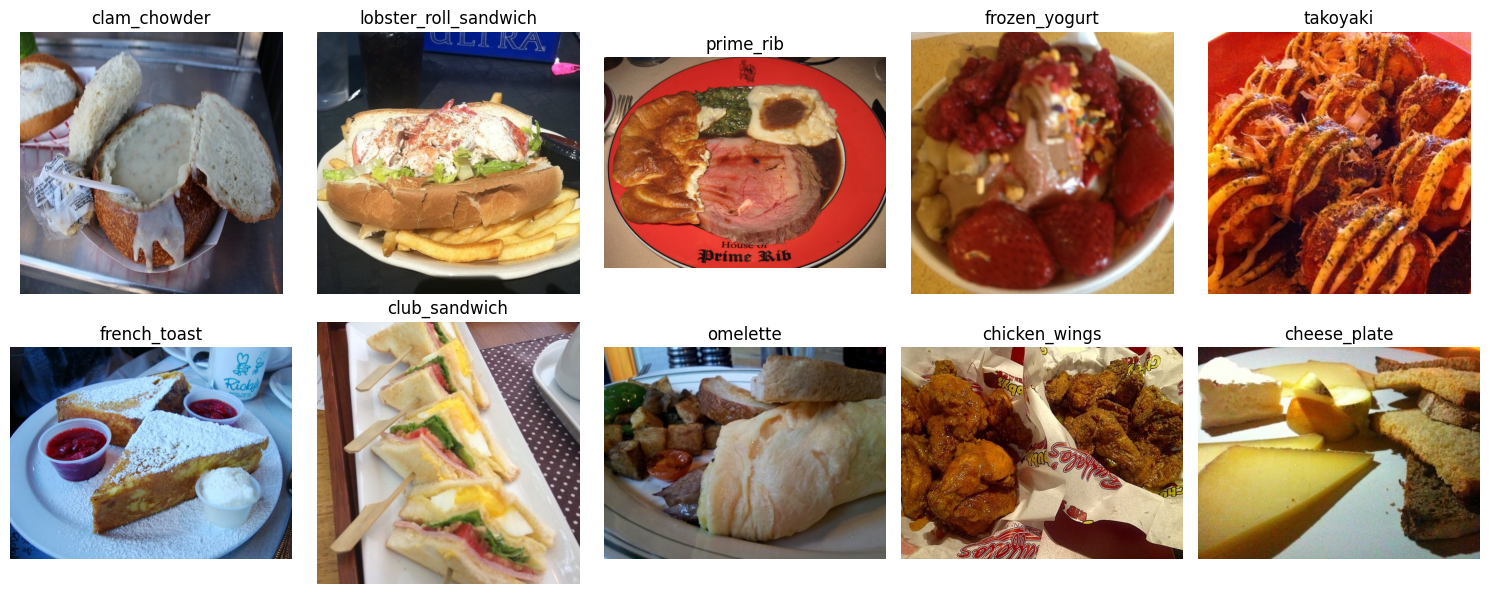

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(classes[:10]):
    cls_path = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_name))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [15]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import torch

# ======================================================
# Speed / Config
# ======================================================
torch.backends.cudnn.benchmark = True

IMG_SIZE        = 224      # 160 instead of 224 speeds training a lot - set back to 224 once everything works
BATCH_SIZE      = 128       # increased to use the GPU better (drop to 64 if you hit Out of Memory)
NUM_WORKERS     = min(4, os.cpu_count() or 2)
USE_SUBSET      = False      # True while iterating/debugging -> trains fast on a fraction of the data
SUBSET_FRACTION = 0.25      # fraction of data used when USE_SUBSET = True

# ======================================================
# Random Seed
# ======================================================
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# ======================================================
# Mean & Std
# (using ready-made ImageNet stats instead of a full pass over the whole
#  dataset just to compute them - that pass alone used to cost real time)
# ======================================================
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
print("Using ImageNet mean/std:", mean, std)

# ======================================================
# Data Augmentation
# (removed RandomAffine - it duplicated RandomRotation and slowed the pipeline for no real gain)
# ======================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# ======================================================
# Dataset Split
# ======================================================
full_dataset = datasets.ImageFolder(root=data_dir)
total = len(full_dataset)
indices = np.random.permutation(total)

if USE_SUBSET:
    subset_len = int(total * SUBSET_FRACTION)
    indices = indices[:subset_len]
    total = subset_len
    print(f"⚠️ SUBSET mode ON: using {total:,} images out of {len(full_dataset):,}")

train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

train_indices = indices[:train_size]
val_indices   = indices[train_size:train_size + val_size]
test_indices  = indices[train_size + val_size:]

train_dataset = Subset(datasets.ImageFolder(data_dir, transform=train_transform), train_indices)
val_dataset   = Subset(datasets.ImageFolder(data_dir, transform=val_transform), val_indices)
test_dataset  = Subset(datasets.ImageFolder(data_dir, transform=val_transform), test_indices)

print(f"\nTrain Images : {len(train_dataset):,}")
print(f"Validation   : {len(val_dataset):,}")
print(f"Test         : {len(test_dataset):,}")
print(f"Classes      : {len(full_dataset.classes)}")

# ======================================================
# DataLoader
# ======================================================
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=NUM_WORKERS > 0, prefetch_factor=4 if NUM_WORKERS > 0 else None
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=NUM_WORKERS > 0, prefetch_factor=4 if NUM_WORKERS > 0 else None
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=NUM_WORKERS > 0, prefetch_factor=4 if NUM_WORKERS > 0 else None
)

images, labels = next(iter(train_loader))
print("\nBatch Shape :", images.shape)
print("Labels Shape:", labels.shape)
print(f"Pixel Range : [{images.min():.2f}, {images.max():.2f}]")


Using ImageNet mean/std: [0.485, 0.456, 0.406] [0.229, 0.224, 0.225]

Train Images : 80,800
Validation   : 10,100
Test         : 10,100
Classes      : 101

Batch Shape : torch.Size([128, 3, 224, 224])
Labels Shape: torch.Size([128])
Pixel Range : [-2.12, 2.64]


In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cpu':
    print("⚠️ Warning: GPU not enabled! Go to Runtime → Change runtime type → T4 GPU")
else:
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
✅ GPU: Tesla T4


ResNet50:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.amp import autocast, GradScaler
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(train_loader.dataset.dataset.classes)

modelR50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

in_features = modelR50.fc.in_features
modelR50.fc = nn.Linear(in_features, num_classes)
modelR50 = modelR50.to(device)

# Freeze الـ backbone كله ودرّب بس آخر بلوك (layer4) + الـ fc
for name, param in modelR50.named_parameters():
    param.requires_grad = False
for name, param in modelR50.layer4.named_parameters():
    param.requires_grad = True
for param in modelR50.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, modelR50.parameters()), lr=1e-3, weight_decay=1e-4)

num_epochs_r50 = 5
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=num_epochs_r50)
scaler = GradScaler("cuda")

model_save_path_r50 = "best_model_resnet50.pth"
best_val_acc_r50 = 0
for epoch in range(num_epochs_r50):
    modelR50.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"ResNet50 Training epoch {epoch+1}"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type="cuda"):
            outputs = modelR50(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss, train_acc = running_loss/total, 100*correct/total

    modelR50.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="ResNet50 Validation"):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with autocast(device_type="cuda"):
                outputs = modelR50(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    val_loss, val_acc = running_loss/total, 100*correct/total

    print(f"Epoch [{epoch+1}/{num_epochs_r50}] Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc_r50:
        best_val_acc_r50 = val_acc
        torch.save(modelR50.state_dict(), model_save_path_r50)
        print("✅ Best ResNet50 model saved.")

print(f"\nBest ResNet50 Validation Accuracy = {best_val_acc_r50:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 162MB/s]
ResNet50 Validation: 100%|██████████| 20/20 [00:14<00:00,  1.38it/s]


Epoch [1/5] Train Acc: 27.15% | Val Acc: 54.97%
✅ Best ResNet50 model saved.


ResNet50 Validation: 100%|██████████| 20/20 [00:11<00:00,  1.71it/s]


Epoch [2/5] Train Acc: 61.98% | Val Acc: 63.88%
✅ Best ResNet50 model saved.


...

Epoch [3/5] Train Acc: 76.87% | Val Acc: 70.06%
✅ Best ResNet50 model saved.


ResNet50 Validation: 100%|██████████| 20/20 [00:11<00:00,  1.72it/s]


Epoch [4/5] Train Acc: 87.91% | Val Acc: 73.94%
✅ Best ResNet50 model saved.


ResNet50 Validation: 100%|██████████| 20/20 [00:12<00:00,  1.65it/s]


Epoch [5/5] Train Acc: 94.65% | Val Acc: 74.85%
✅ Best ResNet50 model saved.

Best ResNet50 Validation Accuracy = 74.85%


EfficientNet-B3:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.amp import autocast, GradScaler
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(train_loader.dataset.dataset.classes)

modelEffB3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

in_features = modelEffB3.classifier[-1].in_features
modelEffB3.classifier[-1] = nn.Linear(in_features, num_classes)
modelEffB3 = modelEffB3.to(device)

# Freeze الـ backbone كله ودرّب بس آخر بلوكين (features[-2:]) + الـ classifier
for name, param in modelEffB3.named_parameters():
    param.requires_grad = False
for name, param in modelEffB3.features[-2:].named_parameters():
    param.requires_grad = True
for param in modelEffB3.classifier.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, modelEffB3.parameters()), lr=1e-3, weight_decay=1e-4)

num_epochs_effb3 = 5
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=num_epochs_effb3)
scaler = GradScaler("cuda")

model_save_path_effb3 = "best_model_effb3.pth"
best_val_acc_effb3 = 0

for epoch in range(num_epochs_effb3):
    modelEffB3.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"EffNet-B3 Training epoch {epoch+1}"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type="cuda"):
            outputs = modelEffB3(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss, train_acc = running_loss/total, 100*correct/total

    modelEffB3.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="EffNet-B3 Validation"):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with autocast(device_type="cuda"):
                outputs = modelEffB3(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    val_loss, val_acc = running_loss/total, 100*correct/total

    print(f"Epoch [{epoch+1}/{num_epochs_effb3}] Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc_effb3:
        best_val_acc_effb3 = val_acc
        torch.save(modelEffB3.state_dict(), model_save_path_effb3)
        print("✅ Best EfficientNet-B3 model saved.")

print(f"\nBest EfficientNet-B3 Validation Accuracy = {best_val_acc_effb3:.2f}%")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 165MB/s]
EffNet-B3 Validation: 100%|██████████| 20/20 [00:20<00:00,  1.03s/it]


Epoch [1/5] Train Acc: 15.77% | Val Acc: 46.42%
✅ Best EfficientNet-B3 model saved.


EffNet-B3 Validation: 100%|██████████| 20/20 [00:11<00:00,  1.79it/s]


Epoch [2/5] Train Acc: 50.31% | Val Acc: 58.97%
✅ Best EfficientNet-B3 model saved.


...

Epoch [3/5] Train Acc: 61.75% | Val Acc: 63.64%
✅ Best EfficientNet-B3 model saved.


EffNet-B3 Validation: 100%|██████████| 20/20 [00:11<00:00,  1.71it/s]


Epoch [4/5] Train Acc: 70.08% | Val Acc: 66.38%
✅ Best EfficientNet-B3 model saved.


EffNet-B3 Validation: 100%|██████████| 20/20 [00:11<00:00,  1.71it/s]

Epoch [5/5] Train Acc: 75.50% | Val Acc: 66.10%

Best EfficientNet-B3 Validation Accuracy = 66.38%


          Model  Best Val Acc (%)  Final Train Acc (%)  Train-Val Gap (%)
       ResNet50             74.61                94.54              19.93
EfficientNet-B3             66.38                75.50               9.12


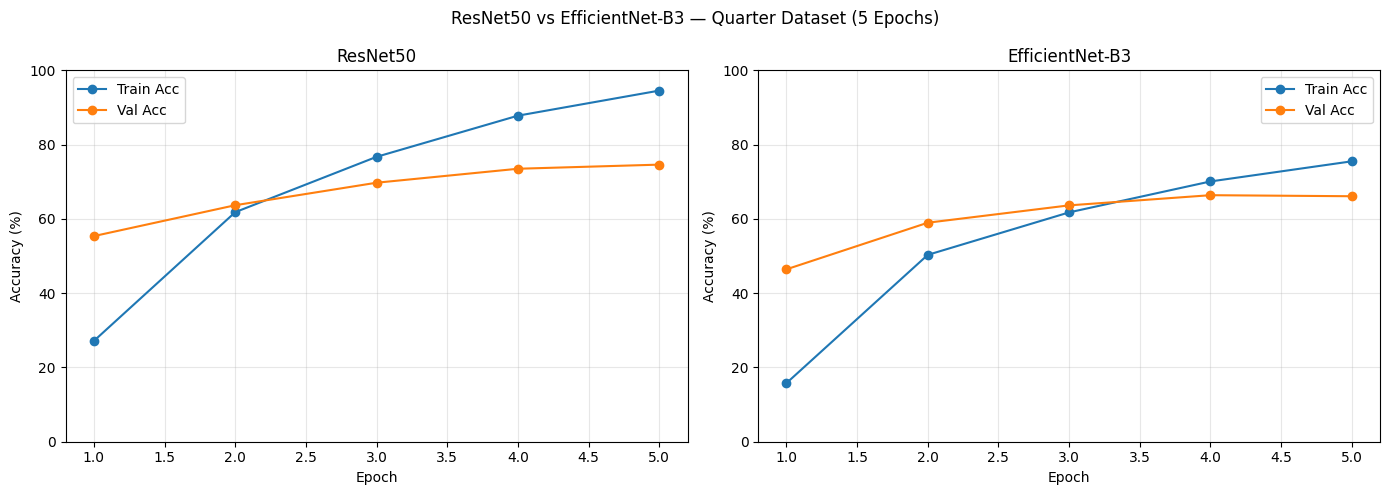

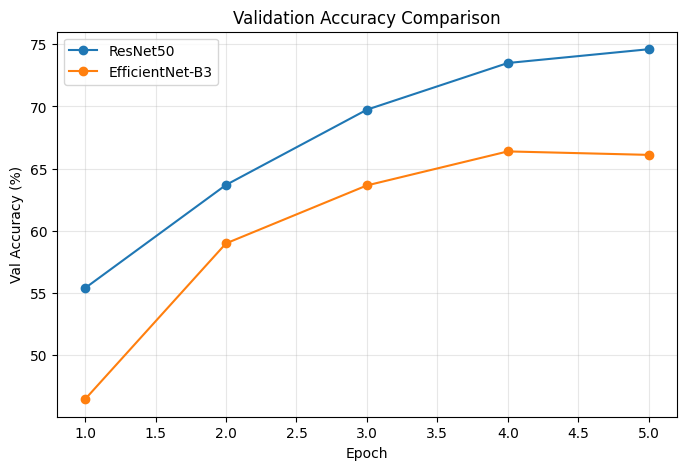

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# نتايج الـ 5 epochs على ربع الداتا (Subset)
# =====================================================
history = {
    "ResNet50": {
        "train_acc": [27.15, 61.81, 76.71, 87.79, 94.54],
        "val_acc":   [55.37, 63.68, 69.74, 73.50, 74.61],
    },
    "EfficientNet-B3": {
        "train_acc": [15.77, 50.31, 61.75, 70.08, 75.50],
        "val_acc":   [46.42, 58.97, 63.64, 66.38, 66.10],
    },
}

epochs = list(range(1, 6))

# =====================================================
# جدول مقارنة سريع
# =====================================================
summary = pd.DataFrame({
    "Model": list(history.keys()),
    "Best Val Acc (%)": [max(h["val_acc"]) for h in history.values()],
    "Final Train Acc (%)": [h["train_acc"][-1] for h in history.values()],
    "Train-Val Gap (%)": [h["train_acc"][-1] - max(h["val_acc"]) for h in history.values()],
})
print(summary.to_string(index=False))

# =====================================================
# رسمة بيانية: Train vs Val لكل موديل
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, h) in zip(axes, history.items()):
    ax.plot(epochs, h["train_acc"], marker="o", label="Train Acc")
    ax.plot(epochs, h["val_acc"], marker="o", label="Val Acc")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("ResNet50 vs EfficientNet-B3 — Quarter Dataset (5 Epochs)")
plt.tight_layout()
plt.show()

# =====================================================
# رسمة واحدة تجمع الـ Val Acc بتاعة الموديلين مع بعض
# =====================================================
plt.figure(figsize=(8, 5))
for name, h in history.items():
    plt.plot(epochs, h["val_acc"], marker="o", label=name)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.amp import autocast, GradScaler
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(train_loader.dataset.dataset.classes)

checkpoint_path = "checkpoint_resnet50_finetune.pth"
best_model_path = "best_model_resnet50_finetune.pth"
warm_start_path = "best_model_resnet50.pth"  # from the earlier quick 5-epoch comparison run

# =====================================================
# Build the model
# =====================================================
modelR50FT = models.resnet50(weights=None)  # architecture only
in_features = modelR50FT.fc.in_features
modelR50FT.fc = nn.Linear(in_features, num_classes)
modelR50FT = modelR50FT.to(device)

# Full fine-tuning: كل الطبقات trainable
for param in modelR50FT.parameters():
    param.requires_grad = True

# =====================================================
# Discriminative learning rates: backbone منخفض جدًا، fc أعلى
# =====================================================
backbone_params = [p for n, p in modelR50FT.named_parameters() if not n.startswith("fc")]
head_params     = [p for n, p in modelR50FT.named_parameters() if n.startswith("fc")]

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": 1e-5},
    {"params": head_params,     "lr": 1e-3},
], weight_decay=1e-4)

num_epochs_ft = 8
patience = 6
scaler = GradScaler("cuda")

# =====================================================
# Resume من checkpoint لو موجود، أو ابدأ من أفضل نتيجة سابقة
# =====================================================
start_epoch = 0
best_val_acc_ft = 0
counter = 0

if os.path.exists(checkpoint_path):
    print(f"🔁 Resuming from checkpoint: {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device)
    modelR50FT.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_acc_ft = ckpt["best_val_acc"]
    counter = ckpt["counter"]
    print(f"   Continuing from epoch {start_epoch}, best Val Acc so far: {best_val_acc_ft:.2f}%")
elif os.path.exists(warm_start_path):
    print(f"⭐ Warm-starting from: {warm_start_path}")
    modelR50FT.load_state_dict(torch.load(warm_start_path, map_location=device))
else:
    print("⚠️ No checkpoint or warm-start weights found - starting from ImageNet weights only.")
    modelR50FT = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    modelR50FT.fc = nn.Linear(in_features, num_classes)
    modelR50FT = modelR50FT.to(device)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs_ft * len(train_loader)
)
for _ in range(start_epoch * len(train_loader)):
    scheduler.step()

# =====================================================
# Train / Validate
# =====================================================
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type="cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100 * correct / total

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100 * correct / total

for epoch in range(start_epoch, num_epochs_ft):
    print(f"\nEpoch [{epoch+1}/{num_epochs_ft}]")
    train_loss, train_acc = train_one_epoch(modelR50FT, train_loader, criterion, optimizer, scheduler, device)
    val_loss, val_acc = validate_one_epoch(modelR50FT, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.2f}%")

    if val_acc > best_val_acc_ft:
        best_val_acc_ft = val_acc
        counter = 0
        torch.save(modelR50FT.state_dict(), best_model_path)
        print("✅ Best fine-tuned ResNet50 saved.")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")

    torch.save({
        "epoch": epoch,
        "model_state": modelR50FT.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_acc": best_val_acc_ft,
        "counter": counter,
    }, checkpoint_path)

    if counter >= patience:
        print("🛑 Early stopping!")
        break

print(f"\nBest Fine-Tuned ResNet50 Validation Accuracy = {best_val_acc_ft:.2f}%")

⭐ Warm-starting from: best_model_resnet50.pth

Epoch [1/8]


Validation: 100%|██████████| 79/79 [00:55<00:00,  1.42it/s]


Train Loss: 1.6378 | Train Acc: 77.83%
Val Loss  : 1.6257 | Val Acc  : 76.99%
✅ Best fine-tuned ResNet50 saved.

Epoch [2/8]


Validation: 100%|██████████| 79/79 [00:54<00:00,  1.46it/s]


Train Loss: 1.4755 | Train Acc: 81.55%
Val Loss  : 1.5688 | Val Acc  : 78.58%
✅ Best fine-tuned ResNet50 saved.

Epoch [3/8]


...

Train Loss: 1.2575 | Train Acc: 87.89%
Val Loss  : 1.4806 | Val Acc  : 80.59%
✅ Best fine-tuned ResNet50 saved.

Epoch [7/8]


Validation: 100%|██████████| 79/79 [00:50<00:00,  1.56it/s]


Train Loss: 1.2344 | Train Acc: 88.51%
Val Loss  : 1.4756 | Val Acc  : 80.57%
No improvement (1/6)

Epoch [8/8]


Validation: 100%|██████████| 79/79 [00:50<00:00,  1.57it/s]


Train Loss: 1.2245 | Train Acc: 88.78%
Val Loss  : 1.4741 | Val Acc  : 80.52%
No improvement (2/6)

Best Fine-Tuned ResNet50 Validation Accuracy = 80.59%


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("best_model_resnet50_finetune.pth", map_location="cuda" if torch.cuda.is_available() else "cpu"))
model = model.to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
from google.colab import files

files.download("best_model_resnet50_finetune.pth")     # الأوزان بس - للاستخدام النهائي / احتياطي
files.download("checkpoint_resnet50_finetune.pth")      # ده اللي فيه الـ optimizer + رقم الـ epoch - محتاجه عشان تكمل التدريب صح

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from google.colab import files
uploaded = files.upload()   # هيفتحلك نافذة تختار منها الملفين من جهازك

Saving checkpoint_resnet50_finetune.pth to checkpoint_resnet50_finetune.pth
Saving best_model_resnet50_finetune.pth to best_model_resnet50_finetune.pth


In [16]:
import os

for fname in ["best_model_resnet50_finetune.pth", "checkpoint_resnet50_finetune.pth"]:
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / (1024*1024)
        print(f"{fname}: {size_mb:.2f} MB")
    else:
        print(f"{fname}: مش موجود")

best_model_resnet50_finetune.pth: 90.78 MB
checkpoint_resnet50_finetune.pth: 271.85 MB


In [19]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.amp import autocast, GradScaler
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(train_loader.dataset.dataset.classes)

checkpoint_path = "checkpoint_resnet50_finetune.pth"
best_model_path = "best_model_resnet50_finetune.pth"
warm_start_path = "best_model_resnet50.pth"  # from the earlier quick 5-epoch comparison run

# =====================================================
# Build the model
# =====================================================
modelR50FT = models.resnet50(weights=None)  # architecture only
in_features = modelR50FT.fc.in_features
modelR50FT.fc = nn.Linear(in_features, num_classes)
modelR50FT = modelR50FT.to(device)

# Full fine-tuning: كل الطبقات trainable
for param in modelR50FT.parameters():
    param.requires_grad = True

# =====================================================
# Discriminative learning rates: backbone منخفض جدًا، fc أعلى
# =====================================================
backbone_params = [p for n, p in modelR50FT.named_parameters() if not n.startswith("fc")]
head_params     = [p for n, p in modelR50FT.named_parameters() if n.startswith("fc")]

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": 1e-5},
    {"params": head_params,     "lr": 1e-3},
], weight_decay=1e-4)

num_epochs_ft = 16
patience = 6
scaler = GradScaler("cuda")

# =====================================================
# Resume من checkpoint لو موجود، أو ابدأ من أفضل نتيجة سابقة
# =====================================================
start_epoch = 0
best_val_acc_ft = 0
counter = 0

if os.path.exists(checkpoint_path):
    print(f"🔁 Resuming from checkpoint: {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device)
    modelR50FT.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_acc_ft = ckpt["best_val_acc"]
    counter = ckpt["counter"]
    print(f"   Continuing from epoch {start_epoch}, best Val Acc so far: {best_val_acc_ft:.2f}%")
elif os.path.exists(warm_start_path):
    print(f"⭐ Warm-starting from: {warm_start_path}")
    modelR50FT.load_state_dict(torch.load(warm_start_path, map_location=device))
else:
    print("⚠️ No checkpoint or warm-start weights found - starting from ImageNet weights only.")
    modelR50FT = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    modelR50FT.fc = nn.Linear(in_features, num_classes)
    modelR50FT = modelR50FT.to(device)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs_ft * len(train_loader)
)
for _ in range(start_epoch * len(train_loader)):
    scheduler.step()

# =====================================================
# Train / Validate
# =====================================================
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type="cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100 * correct / total

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100 * correct / total

for epoch in range(start_epoch, num_epochs_ft):
    print(f"\nEpoch [{epoch+1}/{num_epochs_ft}]")
    train_loss, train_acc = train_one_epoch(modelR50FT, train_loader, criterion, optimizer, scheduler, device)
    val_loss, val_acc = validate_one_epoch(modelR50FT, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.2f}%")

    if val_acc > best_val_acc_ft:
        best_val_acc_ft = val_acc
        counter = 0
        torch.save(modelR50FT.state_dict(), best_model_path)
        print("✅ Best fine-tuned ResNet50 saved.")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")

    torch.save({
        "epoch": epoch,
        "model_state": modelR50FT.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_acc": best_val_acc_ft,
        "counter": counter,
    }, checkpoint_path)

    if counter >= patience:
        print("🛑 Early stopping!")
        break

print(f"\nBest Fine-Tuned ResNet50 Validation Accuracy = {best_val_acc_ft:.2f}%")

🔁 Resuming from checkpoint: checkpoint_resnet50_finetune.pth


/tmp/ipykernel_711/910581460.py:74: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


   Continuing from epoch 8, best Val Acc so far: 80.59%

Epoch [9/16]


Validation: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Train Loss: 1.2210 | Train Acc: 89.06%
Val Loss  : 1.4735 | Val Acc  : 80.63%
✅ Best fine-tuned ResNet50 saved.

Epoch [10/16]


...

Train Loss: 1.2219 | Train Acc: 89.02%
Val Loss  : 1.4727 | Val Acc  : 80.62%
No improvement (1/6)

Epoch [11/16]


Validation: 100%|██████████| 79/79 [00:53<00:00,  1.48it/s]


Train Loss: 1.2210 | Train Acc: 89.04%
Val Loss  : 1.4742 | Val Acc  : 80.60%
No improvement (2/6)

Epoch [12/16]


Training:   2%|▏         | 15/632 [00:17<11:54,  1.16s/it]


KeyboardInterrupt: 

In [20]:
from google.colab import files
files.download("best_model_resnet50_finetune.pth")
files.download("checkpoint_resnet50_finetune.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import torch
import torch.nn as nn
from torchvision import models
from torch.amp import autocast
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(train_loader.dataset.dataset.classes)

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("best_model_resnet50_finetune.pth", map_location=device))
model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

running_loss, correct, total = 0.0, 0, 0
correct_top5 = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with autocast(device_type="cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        _, top5_pred = outputs.topk(5, dim=1)
        correct_top5 += top5_pred.eq(labels.view(-1, 1)).any(dim=1).sum().item()

test_loss = running_loss / total
test_acc_top1 = 100 * correct / total
test_acc_top5 = 100 * correct_top5 / total

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy (Top-1): {test_acc_top1:.2f}%")
print(f"Test Accuracy (Top-5): {test_acc_top5:.2f}%")

Evaluating on Test Set: 100%|██████████| 79/79 [00:54<00:00,  1.44it/s]


Test Loss     : 0.8103
Test Accuracy (Top-1): 80.81%
Test Accuracy (Top-5): 94.70%


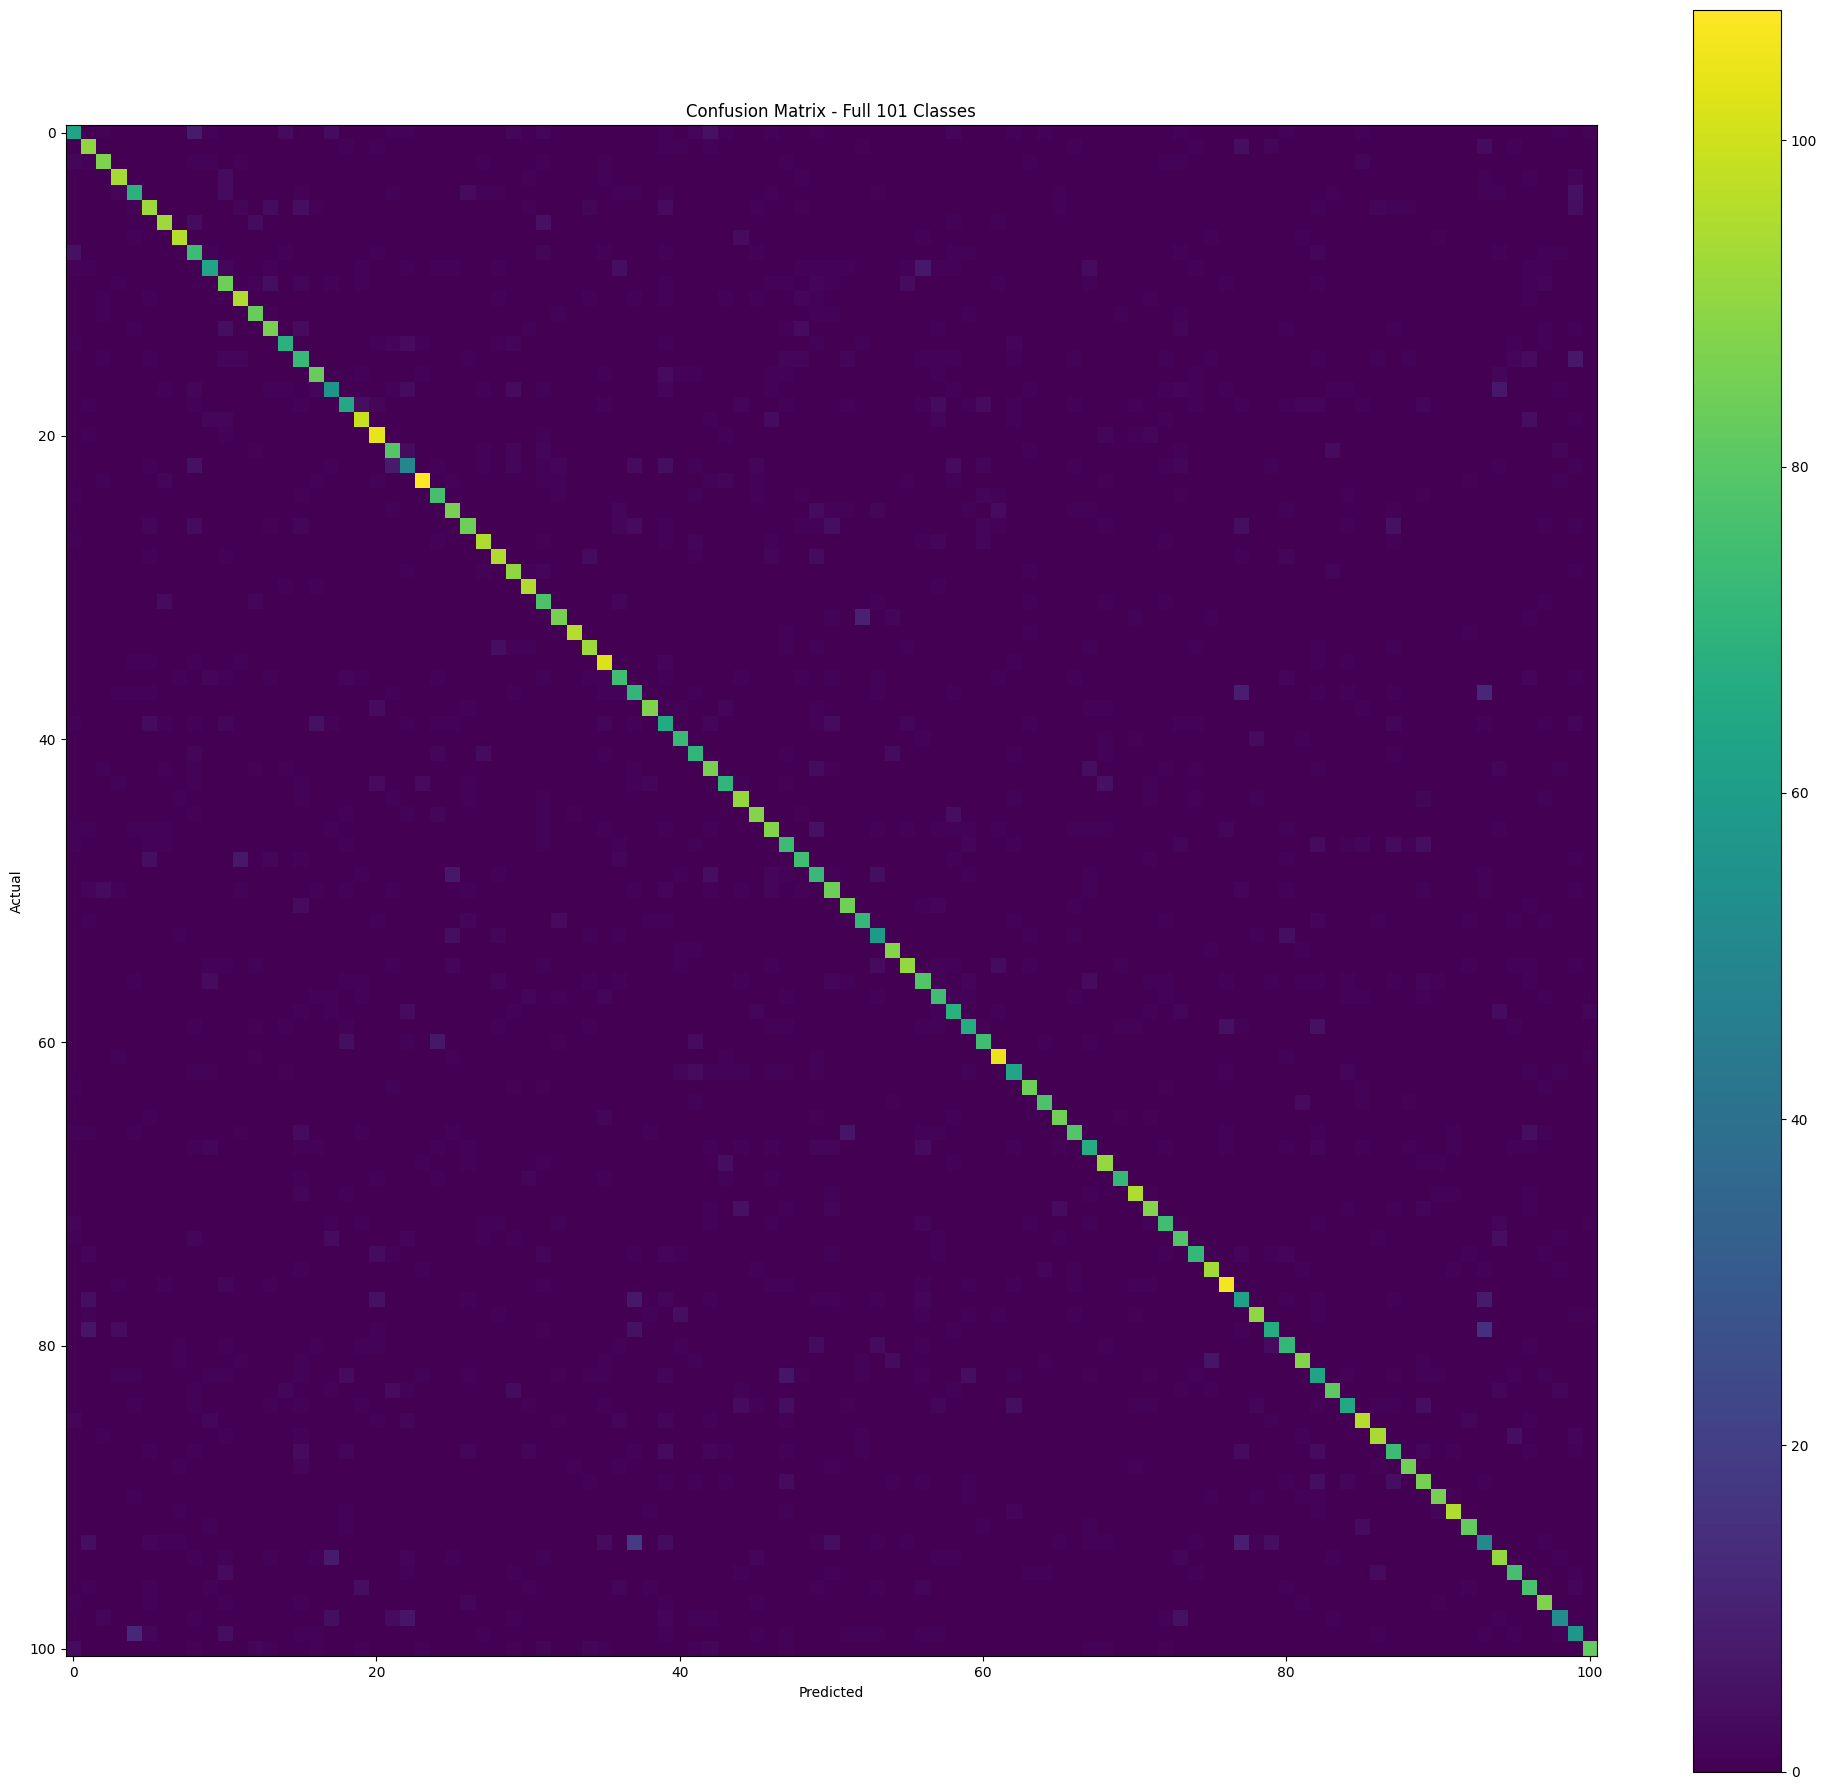

Top 15 most-confused class pairs:

Actual                   Predicted as             Count
-----------------------------------------------------------------
steak                    filet_mignon             19
prime_rib                steak                    15
filet_mignon             steak                    12
tuna_tartare             beef_tartare             12
dumplings                gyoza                    10
filet_mignon             pork_chop                9
steak                    pork_chop                9
apple_pie                bread_pudding            8
chocolate_mousse         chocolate_cake           8
pork_chop                steak                    8
strawberry_shortcake     cheesecake               8
breakfast_burrito        huevos_rancheros         7
ceviche                  tuna_tartare             7
cheesecake               strawberry_shortcake     7
greek_salad              caesar_salad             7


Worst 10 classes (lowest accuracy):

Class              

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_names = train_loader.dataset.dataset.classes

# DataLoader بديل بـ num_workers=0 عشان نتفادى مشكلة "worker exited unexpectedly"
eval_test_loader = DataLoader(
    test_loader.dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)

# =====================================================
# Collect predictions and true labels on the test set
# =====================================================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(eval_test_loader, desc="Collecting predictions"):
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# =====================================================
# 1) Full confusion matrix heatmap - see overall patterns
# =====================================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 18))
plt.imshow(cm, cmap="viridis")
plt.title("Confusion Matrix - Full 101 Classes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix_full.png", dpi=150)
plt.show()

# =====================================================
# 2) Top 15 most-confused class pairs (most useful practically)
# =====================================================
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)  # remove correct predictions, keep only errors

confusions = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_no_diag[i, j] > 0:
            confusions.append((class_names[i], class_names[j], int(cm_no_diag[i, j])))

confusions.sort(key=lambda x: x[2], reverse=True)

print("Top 15 most-confused class pairs:\n")
print(f"{'Actual':<25}{'Predicted as':<25}{'Count'}")
print("-" * 65)
for actual, predicted, count in confusions[:15]:
    print(f"{actual:<25}{predicted:<25}{count}")

# =====================================================
# 3) Worst 10 classes (lowest per-class accuracy)
# =====================================================
per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_classes = sorted(zip(class_names, per_class_acc), key=lambda x: x[1])[:10]

print("\n\nWorst 10 classes (lowest accuracy):\n")
print(f"{'Class':<25}{'Accuracy'}")
print("-" * 40)
for name, acc in worst_classes:
    print(f"{name:<25}{acc*100:.1f}%")

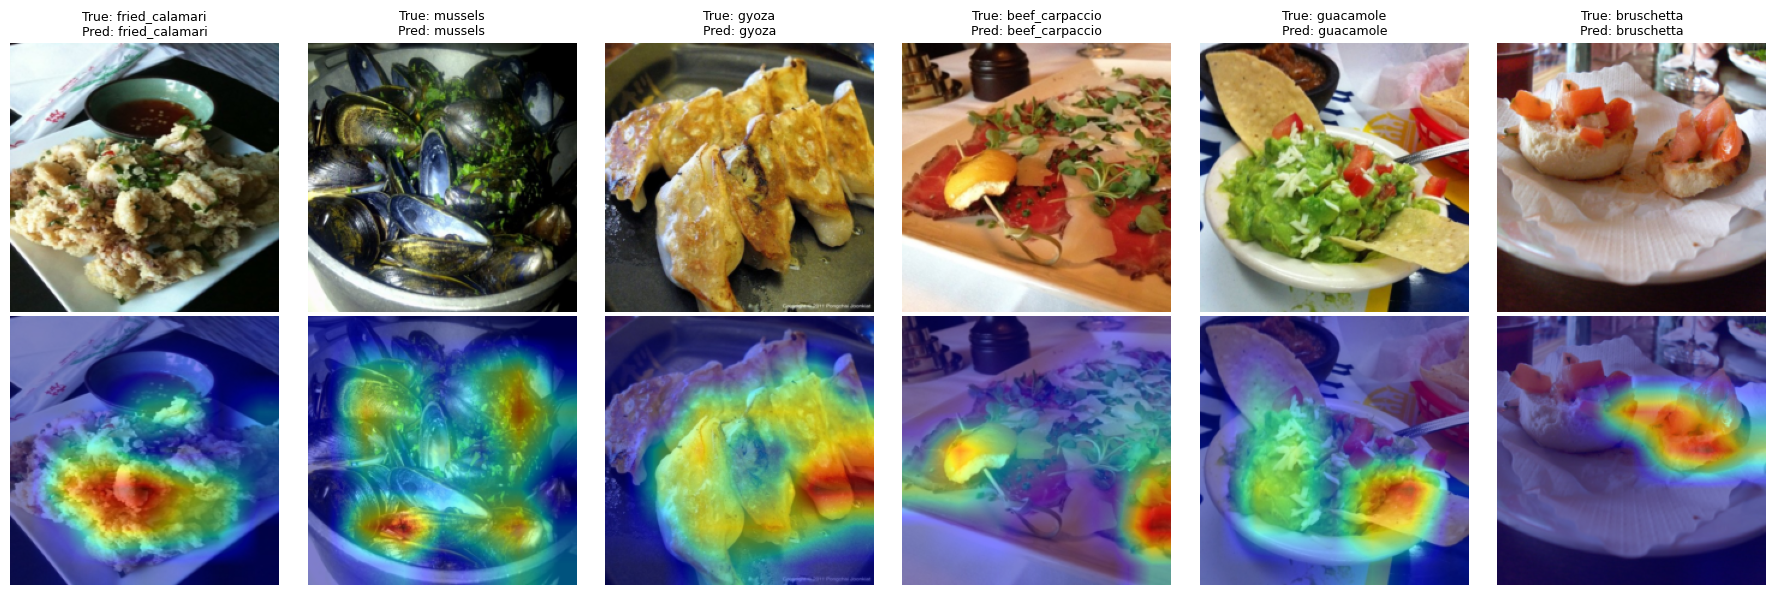

In [33]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_names = train_loader.dataset.dataset.classes

# ImageNet normalization values used in your transforms (needed to un-normalize for display)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# =====================================================
# Grad-CAM implementation for ResNet50 (targets layer4, the last conv block)
# =====================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # global average pooling of gradients
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, output.argmax(dim=1).item()

model.eval()
grad_cam = GradCAM(model, model.layer4[-1])

# =====================================================
# Pick a few test images to visualize (using num_workers=0 loader to avoid the earlier crash)
# =====================================================
eval_test_loader = DataLoader(
    test_loader.dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True
)

images, labels = next(iter(eval_test_loader))
images = images.to(device)

num_to_show = 6
fig, axes = plt.subplots(2, num_to_show, figsize=(3 * num_to_show, 6))

for i in range(num_to_show):
    img_tensor = images[i:i+1]
    true_label = class_names[labels[i].item()]

    cam, pred_idx = grad_cam.generate(img_tensor, labels[i].item())
    pred_label = class_names[pred_idx]

    # un-normalize image for display
    img_disp = images[i].cpu() * std + mean
    img_disp = img_disp.permute(1, 2, 0).clamp(0, 1).numpy()

    axes[0, i].imshow(img_disp)
    axes[0, i].set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(img_disp)
    axes[1, i].imshow(cam, cmap="jet", alpha=0.5)
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("gradcam_examples.png", dpi=150)
plt.show()

In [38]:
import pandas as pd

nutrition_df = pd.read_csv("food101_nutrition.csv").set_index("class_name")

def predict_with_nutrition(model, image_tensor, class_names, device):
    model.eval()
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0).to(device))
        pred_idx = output.argmax(dim=1).item()
        pred_class = class_names[pred_idx]

    info = nutrition_df.loc[pred_class]
    return {
        "class": pred_class,
        "calories_kcal": info["calories_kcal"],
        "protein_g": info["protein_g"],
        "carbs_g": info["carbs_g"],
        "fat_g": info["fat_g"],
    }

sample_img, sample_label = test_loader.dataset[0]
result = predict_with_nutrition(model, sample_img, class_names, device)
print(result)

{'class': 'fried_rice', 'calories_kcal': np.float64(163.0), 'protein_g': np.float64(4.0), 'carbs_g': np.float64(25.0), 'fat_g': np.float64(5.0)}


In [39]:
def get_recommendation(nutrition_info, goal="maintain", allergies=None):
    """
    nutrition_info: dict returned from predict_with_nutrition()
    goal: "lose_weight" | "gain_muscle" | "maintain"
    allergies: list e.g. ["shellfish", "dairy", "nuts"] (optional)
    """
    calories = nutrition_info["calories_kcal"]
    protein  = nutrition_info["protein_g"]
    carbs    = nutrition_info["carbs_g"]
    fat      = nutrition_info["fat_g"]
    food_name = nutrition_info["class"]

    messages = []

    # =====================================================
    # Allergy warnings (highest priority, checked first)
    # =====================================================
    allergy_keywords = {
        "shellfish": ["shrimp", "crab", "lobster", "scallops", "mussels", "oysters", "clam", "calamari"],
        "dairy": ["cheese", "cream", "milk", "cheesecake", "tiramisu", "panna_cotta"],
        "nuts": ["baklava", "macarons"],
        "gluten": ["bread", "pizza", "pasta", "spaghetti", "lasagna", "waffles", "pancakes", "donuts", "churros"],
    }

    if allergies:
        for allergy in allergies:
            keywords = allergy_keywords.get(allergy, [])
            if any(k in food_name for k in keywords):
                messages.append(f"⚠️ Warning: this dish may contain {allergy} - check the ingredients carefully before eating.")

    # =====================================================
    # Recommendation based on the user's goal
    # =====================================================
    if goal == "lose_weight":
        if calories > 300:
            messages.append(f"🔴 Relatively high calories ({calories} kcal/100g) for a weight-loss goal - consider a smaller portion or extra activity.")
        elif calories > 200:
            messages.append(f"🟡 Moderate calories ({calories} kcal/100g) - fine in a reasonable portion.")
        else:
            messages.append(f"🟢 Low calories ({calories} kcal/100g) - a good choice for your goal.")

    elif goal == "gain_muscle":
        if protein >= 20:
            messages.append(f"🟢 High protein ({protein}g/100g) - great for building muscle.")
        elif protein >= 10:
            messages.append(f"🟡 Moderate protein ({protein}g/100g) - consider adding another protein source to the meal.")
        else:
            messages.append(f"🔴 Low protein ({protein}g/100g) - not the best choice for muscle-building on its own.")

    else:  # maintain
        messages.append(f"ℹ️ {calories} kcal | {protein}g protein | {carbs}g carbs | {fat}g fat per 100g.")

    return messages


# =====================================================
# Full example: from image to recommendation
# =====================================================
sample_img, sample_label = test_loader.dataset[0]
nutrition_info = predict_with_nutrition(model, sample_img, class_names, device)
recommendation = get_recommendation(nutrition_info, goal="lose_weight", allergies=["dairy"])

print(f"Detected: {nutrition_info['class']}")
for msg in recommendation:
    print(msg)

Detected: fried_rice
🟢 Low calories (163.0 kcal/100g) - a good choice for your goal.
